# ATP Tennis Match Analysis — Part 2: Statistical Modeling & Hypothesis Testing

**Author:** Akinwale Agesin

This notebook tests four hypotheses about resilience in professional tennis using 15 years of ATP match data (2010–2024). It loads the cleaned datasets produced by `data_pipeline.ipynb` and runs logistic and OLS regression models with full statistical inference.

**Research questions:**
1. Does clutch performance (break-point save rate) predict match outcomes, controlling for rank?
2. After a fatiguing match, do players who serve above their average win their recovery match more often?
3. Does surface specialization help players overcome ranking disadvantages?
4. Do longer previous matches predict worse break-point performance in the next match?

**Data source:** `players_df.csv` and `analysis_df.csv` — generated by `data_pipeline.ipynb`

## I. Introduction <a name="introduction"></a>
_______
### Background Information and Context  <a name= "background"></a>
The dataset used in this project comes from Jeff Sackmann’s open-source ATP tennis repository, a comprehensive archive of professional men’s matches dating back to the 1970s. The data were collected from publicly recorded ATP results and standardized into clean, research-ready CSV files as part of the Tennis Abstract project. By consolidating tournament outcomes, player rankings, match duration, and performance metrics such as break points saved and faced, the dataset allows researchers to study long-term patterns in tennis performance with consistency and precision.

Professional tennis is uniquely demanding. Matches vary widely in length, sometimes finishing in under an hour while others stretch past four hours. These contests occur on different surfaces - clay, grass, and hard courts - that fundamentally change ball speed, player movement, physical load, and how points are constructed. At the same time, matches are often decided by only a few critical points, such as break points and tiebreaks, where mental resilience plays an outsized role. Because of this variation, a player’s ATP ranking alone does not always capture how well they perform under pressure or how effectively they adapt to different playing conditions.

Understanding resilience in tennis is increasingly important for players, coaches, analysts, and fans. <a href = 'https://pmc.ncbi.nlm.nih.gov/articles/PMC11673376/'>Research in sports science</a> shows that fatigue - whether from long matches, dense tournament schedules, or recovery demands - can impair accuracy, reaction time, and decision-making. Likewise, as noted by performance under pressure (“clutch” performance) can swing the outcome of tightly contested matches is the defining characteristic of champions <a href = "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.sa-ijas.org/ojs/index.php/sa-ijas/article/download/30-11/52&ved=2ahUKEwiomOn776GRAxVz1fACHW7KOAkQFnoECCwQAQ&usg=AOvVaw3Gq89SyE4gVG2giHdNRBEm">(Afremow, 2015)</a>. Meanwhile, players often develop long-term strengths on <a href = 'https://bleacherreport.com/articles/1738225-the-most-dominant-players-on-every-surface-in-tennis-history'>specific surfaces</a>, becoming “surface specialists” whose results differ sharply depending on whether they are competing on clay, grass, or hard courts. These elements interact in ways that rankings alone cannot explain.


The goal of this project is to use match-level ATP data to study two dimensions of resilience in men’s tennis:

1. **Short-term resilience (clutch performance):** whether players who perform better on high-pressure points (specifically break points and tiebreaks) are more likely to win matches even after accounting for rank differences (`H1`). 

2. **Long-term resilience (fatigue):** whether players who face long or high-intensity matches show smaller performance declines in their next match, indicating stronger recovery capacity (`H2`).

**Extended Analyses:** We also consider surface specialization as a contextual form of resilience: whether players with extensive experience on a particular surface (clay, grass, or hard) are more likely to exceed ranking-based expectations when playing on their preferred surface (`H3`). Finally, we investigate how these two forms of resilience interact. If fatigue accumulates, players may struggle to execute effectively under pressure. Thus, we test whether longer matches lead to worse break-point performance in the next match, reflecting a decline in clutch ability under fatigue (`H4`).

The results are intended to deepen our understanding of how pressure, fatigue, experience, and match context shape competitive outcomes beyond just ranking alone.


### Key Terms and Data Sources <a name= "key"></a>

Key Terms
- Break Point: situation where the returner/opponent can win the game by winning the next point. It is one of the highest-pressure moments in tennis.
- Clutch Performance: the ability of an athlete to excel when it matters most. The opposite of "choking."
- Logistic Regression: A statistical model used when the outcome is binary - in this case, win vs. loss. Outputs probabilities, not just predictions.
- Linear Regression: A model used to estimate the relationship between a continuous outcome and predictors.
- Odds Ratio: A way of interpreting logistic regression coefficients. It tells you how a one-unit change in a predictor affects the odds of winning.
- Statistical Significance: Indicates that a result is unlikely to have occurred randomly (usually p < 0.05).
- Confidence Interval (CI): A range of plausible values for a coefficient, helpful for understanding uncertainty around estimates.


Attributes Used in Our Analysis
- `surface`: The court type on which the match was played: Hard, Clay, or Grass. Different surfaces change ball speed, bounce height, and physical demands
- `minutes`: The total duration of the match in minutes. This is used as a proxy for fatigue—longer matches typically create greater physical and mental strain.
- `w_bpSaved`/ `w_bpFaced`: Number of break points saved and faced by the match winner.
- `l_bpSaved`/ `l_bpFaced`: Break points saved and faced by the match loser.
- `winner_rank` / `loser_rank`: The ATP ranking of the winning and losing player at the time of the match. Lower numbers indicate better players (e.g., Rank 1 = world #1).
- `w_1stIn` / `l_1stIn`: Winner and Loser's number of first serves made.
- `w_svpt` / `l_svpt`: Winner and Loser's number of serve points.
- `prev_minutes`: The duration of the player’s previous match—used to measure accumulated fatigue heading into the next match.
- `FS_pct_avg`: A player’s yearly average first-serve percentage, representing their typical serving baseline.
- `next_FS_pct_diff`: How the player’s serve performance changed in the next match relative to their yearly baseline.
- `next_win`: Whether the player won their next match (1 = yes, 0 = no).
- `surface_experience`: A proportion measuring specialization. Values close to 1 indicate specialists, who are significantly more experienced on that surface than others.
  

### Research Questions <a name = "researchquestions"></a>
#### How do short-term and long-term resilience dynamics – measured through in-match clutch performance and post-match recovery – jointly predict player success in professional tennis?

To answer this question, we use the following research questions (in order of appearance in this .ipynb file):
1. Do players with stronger clutch performance (i.e., higher break-point conversion)  achieve greater future success, controlling for rank?
2. Does having a better 1st serve percentage after a fatiguing match increase a player’s probability of winning that next match?
3. Are surface specialists more likely to win on their preferred surface, even against higher-ranked opponents?
4. Are longer, more fatiguing matches associated with worse clutch performance on break points?

## II. Data Description <a name="data description and cleaning"></a>
_______
### Background Information and Context  <a name= "motivation"></a>

**Why was the dataset created?**  
Jeff Sackman created the dataset to consolidate decades of fragmented men’s professional-tennis data into an open, reproducible format suitable for research, analytics, and journalism. ATP data previously existed only through paywalled archives or PDFs; this project standardizes it as clean CSV files covering results, rankings, and player stats.

**What tasks does it support?**  
- Player-performance and ranking analytics (e.g., Elo, serve efficiency, clutch analysis)  
- Forecasting match outcomes and tournament simulations  
- Historical trend analysis across surfaces, eras, or player cohorts  

### Funding and Maintenance

The work was self-initiated and self-funded by Jeff Sackmann. There is no record of institutional or corporate sponsorship. Maintenance and updates occur voluntarily through the Tennis Abstract project, supported by community feedback and issue reports. 


### Dataset Composition  

**Observations (Rows)**  
Each row corresponds to a single completed professional tennis match – tour-level, challenger, or futures – identified by tourney_id and match_num.

**Attributes (Columns)**  
Below are the main raw variables we use from the ATP match files, with a short description and how each is measured.

<u>Tournament context:<u/>
- tourney_id – Unique identifier for the tournament (string).  
- tourney_name – Name of the tournament (text).  
- tourney_date – Date of the match in YYYYMMDD format.   
- surface – Court surface for the match, recorded as "Hard", "Clay", or "Grass" (categorical).  

<u> Match information<u/>  
- minutes – Length of the match in minutes (numeric).  

<u> Players<u/>  
- winner_id – Unique identifier for the winning player (string).  
- loser_id – Unique identifier for the losing player (string).  
- winner_name – Name of the winning player (text).  
- loser_name – Name of the losing player (text).  

<u> Performance metrics (break points)<u/>   
- w_bpSaved – Number of break points the winner saved while serving in that match (count).  
- w_bpFaced – Number of break points the winner faced while serving in that match (count).  
- l_bpSaved – Number of break points the loser saved while serving in that match (count).  
- l_bpFaced – Number of break points the loser faced while serving in that match (count).  

<u> Context (ranking and score)<u/>   
- winner_rank – Winner’s ATP ranking at the time of the match (integer; 1 = highest ranked).  
- loser_rank – Loser’s ATP ranking at the time of the match (integer).  
- score – Final score of the match, written set by set as a single string (for example, "6-4 7-5").  


### Data Coverage  

ATP rankings: mostly complete from 1985 to present; 1973 - 1984 are intermittent; 1982 is missing.


### Data Collection Process  

**Collection**  
Data were aggregated from publicly available ATP sources (match results, player biographies, and rankings). Sackmann manually reconciled inconsistencies, added redundant biographical fields for usability, and filtered implausible entries.

**Time Frame**  
The dataset has been continuously updated since the mid-2000s and includes historical back-filled records dating to 1973 when available.

**Human Involvement**  
No individuals were surveyed; the dataset draws exclusively from publicly recorded match information.

**Influencing Processes**  
Recording conventions folow ATP official scoring and data feeds. Older matches lack detailed statistics, so data availability and completeness vary by era. Occasional gaps or errors reflect the ATP’s archival limits rather than the curator’s sampling choices.


### Data Preprocessing  

**Creator Procedures (on raw repository)**  
Sackmann deleted implausible entries (e.g., loser winning >60 % of points or match < 20 min) and applied “sanity checks”. Redundant player/ranking fields were intentionally added to minimize the need for cross-file joins. The result is a self-contained match table suited for simple statistical work without requiring database merges.

**Derived Subset**  
The raw repository provides full-season match files with many variables. Users can construct their own subsets (for example, restricting to certain years, levels, or surfaces) and derive new variables for specific analyses. Our specific choices are described in the Data Cleaning section.


### Dataset Distribution  

**Access**  
Raw files publicly available: https://github.com/JeffSackmann/tennis_atp.git

**Format**  
Plain CSV; one file per season.

**Update Cycle**  
Annual postseason updates by Sackmann

**Maintenance**  
Issues accepted via GitHub


### Legal and Ethical Concerns  

**License**  
Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)

**Bias**  
Earlier decades have more missing statistics, so detailed analyses based on this dataset mainly reflect modern ATP play. This should be kept in mind when interpreting and generalizing results.


## III. Data Cleaning <a name="data cleaning"></a>
_______

In order to prepare the tennis match dataset for analysis, we conducted an extensive data-cleaning process. The full data cleaning and feature engineering pipeline is documented in `data_pipeline.ipynb`.

**Data Cleaning Overview:**

To prepare the ATP match data for analysis, we first converted tournament dates into a standard datetime format and sorted matches chronologically. This ensured that any time-dependent variables - such as previous match duration or next-match outcomes - were computed in the correct sequence. We then reshaped the dataset from match level to player-match level by separating winners and losers into aligned datasets, standardizing variable names, and calculating key performance measures such as first-serve percentage (`FS_pct`) and clutch performance (`clutch`) based on break-point statistics.

Next, we constructed the fatigue (`prev_minutes`) and recovery (`FS_pct_diff`) variables needed for our resilience research. For macro-level fatigue, we computed each player’s previous match duration by aligning matches within each player’s history. For recovery metrics, we calculated each player’s yearly first-serve baseline and measured match-level deviations from this norm, then linked each match to the player’s subsequent match to attach next-match outcomes and next-match serving performance.

Because ATP rankings appear in separate winner and loser columns, we standardized ranking into a single variable representing each player’s rank in every match. We also calculated the match-level ranking gap (`rank_diff`) and merged it onto all player-match rows, providing a consistent measure of opponent difficulty. To incorporate contextual expertise, we computed surface specialization (`surface_experience`) as the proportion of each player’s career matches played on the surface of the current match.

Finally, we filtered out incomplete observations (such as missing fatigue values or match durations) to ensure our models were based on clean, reliable data. The resulting dataset (`players_df`) and its subset data set (`analysis_df`) includes standardized performance metrics, fatigue and recovery features, ranking and matchup context, and surface specialization indicators, all aligned with our four research questions on clutch performance, next-match recovery, surface expertise, and fatigue-related clutch decline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Load cleaned datasets produced by data_pipeline.ipynb
players_df  = pd.read_csv('players_df.csv')
analysis_df = pd.read_csv('analysis_df.csv')
print(f"players_df:  {players_df.shape}")
print(f"analysis_df: {analysis_df.shape}")

## IV. Preregistration Statements <a name="preregistration statements"></a>

The following preregistration outlines how we will evaluate each hypothesis, what statistical models will be used, and how we will interpret coefficients, p-values, and confidence intervals. All hypothesis tests will use a significance threshold of **α = 0.05**.
_______

### Hypothesis 1: Short-Term Resilience: Clutch Performance and Success
**Hypothesis**  

Players with stronger clutch performance - measure by higher break-point save rates - will have a higher probability of winning the match, controlling for rank. We expect a positive relationship between clutch performance and match success after accounting for skill differences.


**Model**  

To evalutate hypothesis 1, We will use a logistic regression to model the probability of winning as a function of clutch performance:

$$\text{logit}(\Pr(\text{win}=1)) = \beta_0 + \beta_1 \cdot \text{clutch} + \beta_2 \cdot \text{rank} + \varepsilon$$

Here, the outcome variable is `win` (1 = won the match, 0 = lost) and the key predictor is `clutch` while being controlled for `rank`.


**Criteria**

We will use coefficient-based inference, not prediction accuracy, to evaluate Hypothesis 1. The hypothesis will be supported if:
1.  $\beta_1$ > 0 (direction: better clutch performance increases win probability),
2.  p-value($\beta_1$) < 0.05 (statistical significance),
3.  The 95% confidence interval for $\beta_1$ excluding 0,
4.  The odds ratio for clutch > 1, indicating an increase in win likelihood per unit of clutch performance.

Interpretation will focus on the size and direction of $\beta_1$ and its odds-ratio transformation. Model fit (pseudo R$^2$, AIC) will be reported for completeness but will not be used as hypothesis evidence.

### Hypothesis 2: Long-Term Resilience: Recovery and Success
**Hypothesis** 

Following a fatiguing match, players who serve better than their yearly baseline in their next match will have a higher probability of winning that next match. We expect that positive deviations in first-serve percentage (relative to the player’s own seasonal norm) reflect stronger recovery and therefore increase match success.


**Model**  

To test hypothesis 2, we will fit a logistic regression predicting next-match success from improvement in first-serve percentage:
$$ \text{logit}(\Pr(\text{next\_win} = 1)) = \beta_0 + \beta_1 \cdot \text{next\_FS\_pct\_diff} + \varepsilon $$

Here, the outcome variable is `next_win` (1 = player wins their next match, 0 = they lose) and the key predictor is `next_FS_pct_diff`. 

We sample all player-match observations with valid previous match durations, yearly serve baselines, and linked next-match outcomes. Addtionally, we assume improvements in serve performance reflect recovery rather than long-term skill differences, which are already absorbed into yearly baselines.


**Criteria**

Evidence for Hypothesis 2 will be based solely on the coefficient for `next_FS_pct_diff` $\beta_1$. The hypothesis will be supported if:
1. $\beta_1$ > 0 (direction: better-than-usual serving improves next-match win probability),
2. p-value ($\beta_1$) < 0.05,
3. The 95% CI for $\beta_1$ excludes 0,
4. The odds ratio for next_FS_pct_diff > 1, indicating increased odds of winning per unit improvement in serving performance.

Prediction accuracy or AUC will not be used for hypothesis testing; only coefficient-based inference is relevant.


### Hypothesis 3: Surface Specialization

**Hypothesis**  

Players will perform better on the surface where they have accumulated the most experience, and this specialization will moderate the impact of ranking differences on match outcomes. Specifically, surface specialists are expected to reduce the performance disadvantage typically associated with facing higher-ranked opponents when competing on their preferred surface.

**Model**  

To evaluate hypothesis 3 we will fit a logistic regression model with an interaction between rank difference and surface specialization:

$$ \text{logit}(\Pr(\text{win} = 1)) = 
\beta_0 + \beta_1 \cdot \text{rank\_diff} + \beta_2 \cdot \text{surface\_experience} + \beta_3 (\text{rank\_diff} \times \text{surface\_experience}) + \beta_{\text{surface}} + \varepsilon $$

Here, the outcome variable is `win` ((1 = won the match, 0 = lost) and the key predictors are `rank_diff` (measuring expected skill gap, `surface_experience` (proportion of player's matches on the current surface), and the interaction term of `rank_diff` x surface_experience. Addtionally, it controls for `surface`: We add dummy variables for surface type so that we adjust for the inherent differences between clay, grass, and hard courts, ensuring the effect of surface experience is not confounded by the surface itself.

**Criteria**

The focal point for hypothesis 3 is the interaction coefficient $\beta_3$ which tests whether surface specialization moderates the effect of ranking differences on match outcomes. The hypothesis will be supported if:
1. $\beta_3$ > 0 (specialization weakens the disadvantage of facing a better-ranked opponent),
2. p-value($\beta_3$) < 0.05,
3. The 95% confidence interval for $\beta_3$ excludes 0,
4. The predicted win-probability plots show that specialists maintain higher win odds across ranking gaps than non-specialists when competing on their preferred surface.


### Hypothesis 4: Interaction of Fatigue and Clutch Performance

**Hypothesis**  

Players who enter a match with higher accumulated fatigue — measured by the duration of their previous match— will exhibit weaker clutch performance on break points. We expect clutch ability to decline as prior match duration increases, reflecting how physical and mental fatigue diminishes performance under pressure

**Model**  

To evaluate hypothesis 4, we will fit the following linear regression model:
$$ \text{clutch} = \beta_0 + \beta_1 \cdot \text{prev\_minutes} +\beta_2 \cdot \text{rank} + \beta_{\text{surface}} + \varepsilon$$

Here, the outcome variable is `clutch` and the key predictor is `prev_minutes` while controlling for `rank` to adjust for skill differences and `surface to adjust for inherent differences of court types.

**Criteria**

Hypothesis 4 will focus on $\beta_1$, the slope on previous-match duration. To support this hypothesis we require:
1. $\beta_1$ (direction: greater fatigue leads to weaker clutch performance),
2. p-value($\beta_1$) < 0.05,
3. A 95% confidence interval for α₁ that excludes 0.

We will also report the models R$^2$, residual diagnostics, and a visualization of the fitted regression line over the scatterplot of clutch vs. previous match duration. However, hypothesis evaluation will rely solely on the coefficient-based inference for $\beta_1$.

## V. Data Analysis <a name="data analysis"></a>
_______

### Hypothesis 1: Short-Term Resilience: Clutch Performance and Success
**Null Hypothesis $H_0$**: Players with stronger clutch performance do not have a higher probability of winning matches. Equivalently: _$B_{Clutch}$ = 0_.

**Alternative Hypothesis $H_1$**: Players with stronger clutch performance (i.e., higher break-point conversion) will have a higher probability of winning the match, controlling for rank. _$B_{Clutch}$ != 0_.

In [2]:
h1_df = players_df[['clutch', 'rank', 'win']].dropna()

X= h1_df[['clutch', 'rank']]
X=sm.add_constant(X)
y= h1_df['win']

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

model = sm.Logit(y_train, X_train).fit()

#coefficient summary for inference
print(model.summary())

#predictions on train and test data
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

# Turn probabilities into 0/1 labels with 0.5 threshold
y_train_pred = (y_hat_train >= 0.5).astype(int)
y_test_pred = (y_hat_test >= 0.5).astype(int)

#Evaluation metrics: accuracy + AUC for train and test data
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_hat_train)
test_auc = roc_auc_score(y_test, y_hat_test)


print(f'''Train Accuracy: {round(train_accuracy,3)}''')
print(f'''Test Accuracy: {round(test_accuracy,3)}''')
print(f'''Train AUC: {round(train_auc,3)}''')
print(f'''Train AUC: {round(test_auc,3)}''')

Optimization terminated successfully.
         Current function value: 0.671889
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                46572
Model:                          Logit   Df Residuals:                    46569
Method:                           MLE   Df Model:                            2
Date:                Fri, 05 Dec 2025   Pseudo R-squ.:                 0.03002
Time:                        23:01:46   Log-Likelihood:                -31291.
converged:                       True   LL-Null:                       -32260.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1364      0.023     -5.945      0.000      -0.181      -0.091
clutch         0.9540      0.

This logistic regression predicts the probability of winning a match from clutch performance (break-point save rate), controlling for rank.

$$\text{logit}(\Pr(\text{win}=1)) = -0.1364 + 0.9540 \times \text{clutch} + -0.0054 \times \text{rank}$$


**Relationship Summary**

The model shows a strong and statistically significant positive relationship between clutch and winning; specifically, a 0.1 increase in clutch multiplies the odds of winning by e$^{0.0954}$ = 1.10. In other words, a 0.1 increase in clutch performance is associated with an increase of 10% in the odds of winning a match.

Addtioanlly, there is a statisitcially significant negative relationshop between rank and winning; specifically, for a 1-place increase in rank (i.e., worse ranking), the odds of winning decrease by 100 x (e$^{-0.0054}$ - 1) = 0.54%. The negative relationship makes sense as a higher rank number means worse player.


**Model Predictions**

**<u>I.</u>**
The proability that when clutch is 0 and rank is controlled at is median, the predicted probabaility of winning is e$^a$ / (e$^a$ +1): $$ p = e^{-0.3956} / 1 + e^{-0.3956} = 0.402$$ 
So, a baseline player (clutch score 0, rank 48) has about a 40.2% chance of winning a match.

**<u>II.</u>**
When clutch is 1 (meaning that a player saves all of the break-points they face) and rank is controlled for with the use of its median, the predicted probabaility of winning is 0.636. This is derived by:

$$\text{logit}(\text{p}) = -0.1364 + 0.9540 \times 1 + -0.0054 \times rank.median() $$
$$= -0.1364 + 0.9540 \times 1 + -0.0054 \times 48 $$
$$= 0.5584$$

$$\text{and}$$

$$ p = e^{0.5584} / 1 + e^{0.5584} = 0.636$$ 
So, a player with clutch = 1 and median rank = 48 has a predicted probability of winning of about 63.6%.


**<u>III.</u>**
Addtionally, when clutch is 0.5 (meaning that a player saves half of the break they face) and rank is controlled for with the use of its median, the predicted probabaility of winning is 0.520 derived by:
$$\text{logit}(\text{p}) = -0.1364 + 0.9540 \times 0.5 + -0.0054 \times rank.median() $$
$$= -0.1364 + 0.9540 \times 0.5 + -0.0054 \times 48 $$
$$= 0.0814$$

$$\text{and}$$

$$ p = e^{0.0814} / 1 + e^{0.0814} = 0.520$$ 

So, a player with clutch = 0.5 and median rank = 48 has a predicted win probability of about 52.0%.


**Outliers/Oddities**

We expect this model to hold for clutch values between 0 and 1, which is both the observed range of the data and the theoretical limits of the clutch metric (a proportion of break points saved). If the model were used to predict the probability of winning at clutch values outside this range, the estimated relationship would constitute extrapolation beyond the scope of the model, and the positive relationship between clutch and winning may not hold. For example, at clutch values less than 0 or greater than 1, the model would continue to return numerical predicted probabilities even though such clutch values are impossible in real tennis play; these predictions are therefore nonsensical and should not be interpreted.

With respect to outliers, the data naturally contain heavy clustering at clutch = 0 and clutch = 1, because many players face only a small number of break points and thus often either save all of them or none. The residual plot does not reveal any extreme or influential observations that deviate sharply from the modeled relationship, nor does it show heteroskedstic patterns that would suggest the need for an alternative, transformed model. 

**Model Accuracy and AUC**

Model diagnostics indicate good generalization performance, with train accuracy = 0.569, test accuracy = 0.566, we know that this model is not overfitting to the trained data. Addtionally, the model holds nearly identical AUC values (train AUC = 0.637, test AUC = 0.635). Because our primary goal is inference, these metrics are used to confirm that the model is not severely overfitting and that its estimates are stable across training and held-out data.

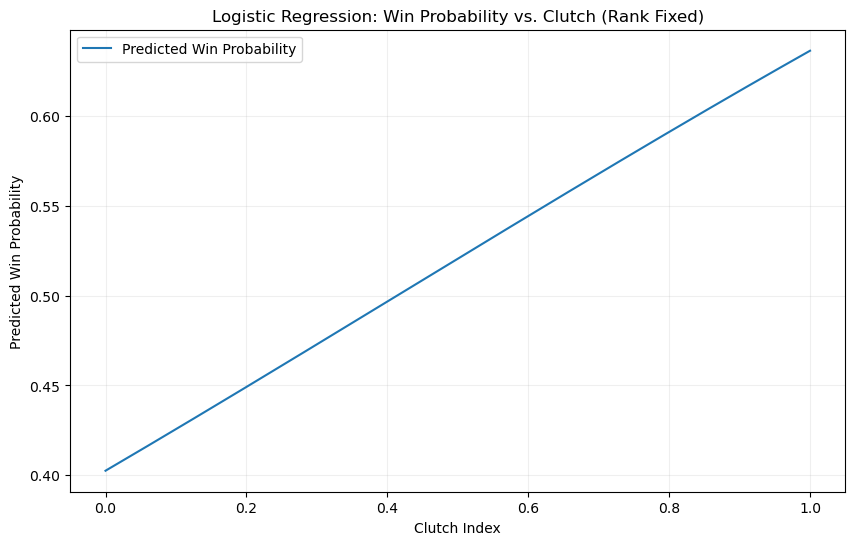

In [3]:
#Range of clutch values
clutch_range = np.linspace(0, 1, 200)

#Hold rank fixed at a typical value (median)
rank_fixed = h1_df['rank'].median()

#Build X_new with ALL predictors used in the model (NO constant yet)
X_new = pd.DataFrame({
    'clutch': clutch_range,
    'rank': rank_fixed})

#Add the constant term so columns match X_train
X_new = sm.add_constant(X_new, has_constant='add')

#Predict win probabilities using the FITTED model
pred_probs = model.predict(X_new)

#Plot
plt.figure(figsize=(10, 6))
plt.plot(clutch_range, pred_probs, label='Predicted Win Probability')
plt.xlabel("Clutch Index")
plt.ylabel("Predicted Win Probability")
plt.title("Logistic Regression: Win Probability vs. Clutch (Rank Fixed)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

To visualize the effect of clutch performance on success, we plot the model-predicted win probability across the full range of the clutch index (0–1), holding rank fixed at the median. The curve shows a clear positive relationship: players with very low clutch values have an expected win probability of about 40%, whereas highly clutch players have probabilities exceeding 60%. This visualization complements the regression table by translating the log-odds coefficient into an intuitive probability scale, making the effect size and monotonic pattern clear. The plot also confirms that the model behaves smoothly with no unusual nonlinearities, supporting the validity of the logistic specification.

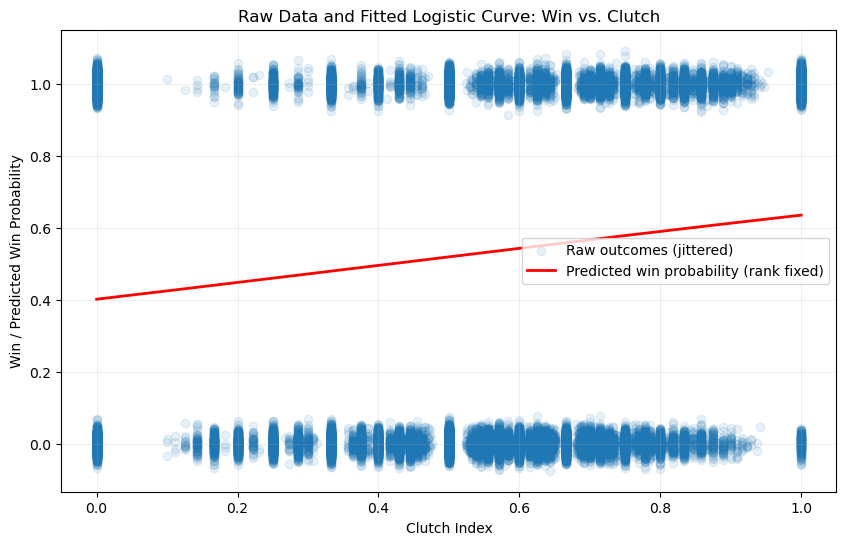

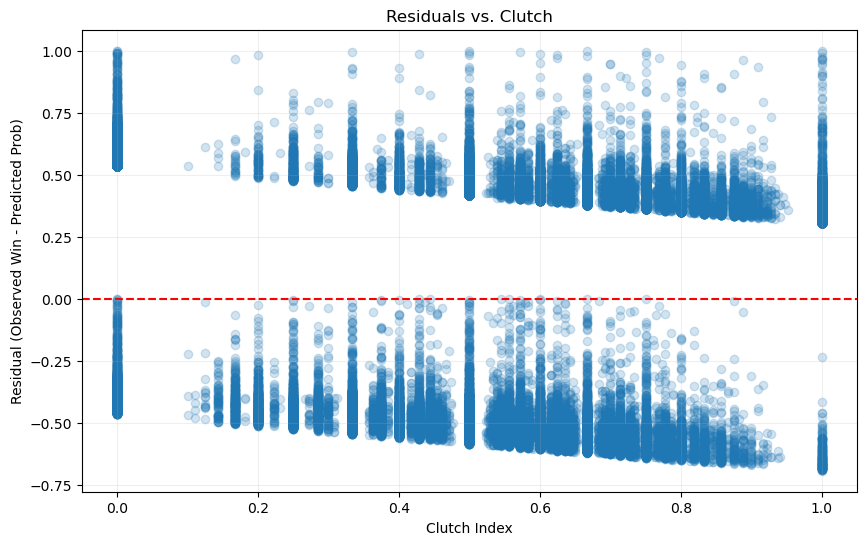

In [4]:
#1. RAW DATA+FITTED CURVE (TRAINING DATA) ---

#training clutch and outcomes
clutch_train = X_train['clutch']
win_train = y_train

#predicted probabilities
p_train = model.predict(X_train)

#jitter binary outcomes a bit to prevent overlapping points at 0/1
y_jitter = win_train + np.random.normal(0, 0.02, size=len(win_train))

#curve: clutch with rank fixed at median
clutch_range = np.linspace(0, 1, 200)
rank_fixed = h1_df['rank'].median()
X_curve = pd.DataFrame({
    'const': 1.0,
    'clutch': clutch_range,
    'rank': rank_fixed
})
p_curve = model.predict(X_curve)

plt.figure(figsize=(10, 6))
plt.scatter(clutch_train, y_jitter, alpha=0.1, label='Raw outcomes (jittered)')
plt.plot(clutch_range, p_curve, color='red', linewidth=2,
         label='Predicted win probability (rank fixed)')
plt.xlabel("Clutch Index")
plt.ylabel("Win / Predicted Win Probability")
plt.title("Raw Data and Fitted Logistic Curve: Win vs. Clutch")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

#residuals: observed-predicted
residuals = win_train - p_train

plt.figure(figsize=(10, 6))
plt.scatter(clutch_train, residuals, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Clutch Index")
plt.ylabel("Residual (Observed Win - Predicted Prob)")
plt.title("Residuals vs. Clutch")
plt.grid(alpha=0.2)
plt.show()

**Raw Data Fit Plot**

We also compare the fitted logistic curve to the raw match outcomes by plotting the jittered binary win values against clutch. The raw data display the expected pattern: observations cluster at win = 1 and win = 0, and the proportion of wins increases with higher clutch values. The fitted logistic curve passes through the center of the observed data cloud, demonstrating that the model captures the overall association between clutch and winning.

The concentration of clutch values around 0 and 1 is expected given the definition of clutch as the proportion of break points saved; many matches involve only one or two break points, making perfect success (1.0) or complete failure (0.0) common. This distributional characteristic does not violate model assumptions and is appropriate for logistic modeling


**Residual Plot**

To further examine the fit of this model, we examined a residual plot of observed win minus predicted win probability against the clutch index. Residuals are approximately centered around zero across the range of the clutch, with no clear non-linear pattern. The vertical bands of residuals seen at particular clutch values reflect the discrete nature of the clutch measure (many matches have only a few break points, leading to repeated values of 0, 0.5, 1.0, etc.) and do not by themselves indicate misspecification.

Due to it being a logistic regression, the fan-shaped dispersion seen in some regions of the plot is expected and does not violate our model assumptions.

### Hypothesis 2: Long-Term Resilience: Recovery and Success
**Null Hypothesis $H_0$**: For matches following a fatiguing match, recovery performance (`next_FS_pct_diff`) is not related to the probability of winning the recovery match. Equivalently: _$B_{recovery}$ = 0_, meaning that the coefficient on the recovery metric in the win-probability model is zero.

**Alternative Hypothesis $H_1$**: For matches following a fatiguing match, better 1st serve percentage (an indicator of recovery performance) is associated with a higher probability of winning a player's next match. _$B_{Recovery}$ != 0_.

**Identifying Fatiguing Matches & Running Recovery Regression**

To test whether players who recover better after fatiguing matches are more likely to win their next match, we begin by examining the distribution of match durations using a boxplot and define a “fatiguing match” as any match whose duration lies above the 75th percentile (the top 25% of longest matches are treated as high-fatigue events).

After establishing this threshold, we restrcit the dataset to these fatiguing matches as they represent the situations where physical recovery should matter most, making them appropriate for analyzing whether recovery ability influences subsequent performance.

To link players' fatiguing (match N) and recovery matches (N+1), we retain only cases where (a) the player actually had a subsequent match, and (b) that next match occurred within the same calendar year.

Finally, we test whether serving better than usual in the recovery match (`next_FS_pct_diff`) increases the probability of winning that recovery match (`next_win`).

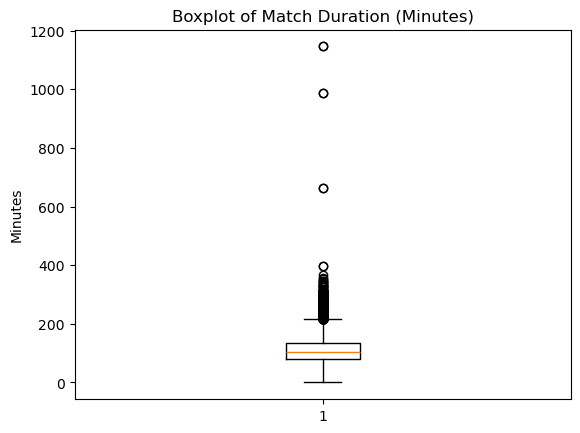

Optimization terminated successfully.
         Current function value: 0.685675
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:               next_win   No. Observations:                15055
Model:                          Logit   Df Residuals:                    15053
Method:                           MLE   Df Model:                            1
Date:                Fri, 05 Dec 2025   Pseudo R-squ.:                0.006440
Time:                        23:01:47   Log-Likelihood:                -10323.
converged:                       True   LL-Null:                       -10390.
Covariance Type:            nonrobust   LLR p-value:                 5.992e-31
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1553      0.016      9.455      0.000       0.123       0.187
next_FS_pct

In [5]:
#Fatigue threshold (top 25% of minutes)
plt.boxplot(players_df['minutes'].dropna())
plt.title("Boxplot of Match Duration (Minutes)")
plt.ylabel("Minutes")
plt.show()

fatigue_threshold = players_df['minutes'].quantile(0.75)

#Filter to only fatiguing matches (match N)
fatigue_df = players_df[players_df['minutes'] >= fatigue_threshold].copy()

#Keep only cases where we have a next match AND it is in the same year
fatigue_df = fatigue_df.dropna(subset=['next_win', 'next_FS_pct_diff', 'next_year'])
fatigue_df = fatigue_df[fatigue_df['tourney_year'] == fatigue_df['next_year']]

#Logistic Regression: does serving better-than-usual in the match AFTER
#a fatiguing match (next_FS_pct_diff) increase the probability of winning that next match (next_win)?

X = sm.add_constant(fatigue_df['next_FS_pct_diff'])
y = fatigue_df['next_win']

model = sm.Logit(y, X).fit()
print(model.summary())

This logistic model predicts the regression line:

$$\text{logit}(P(\text{next\_win}=1))= 0.1553 + 2.8933 * \text{next\_FS\_pct\_diff}$$

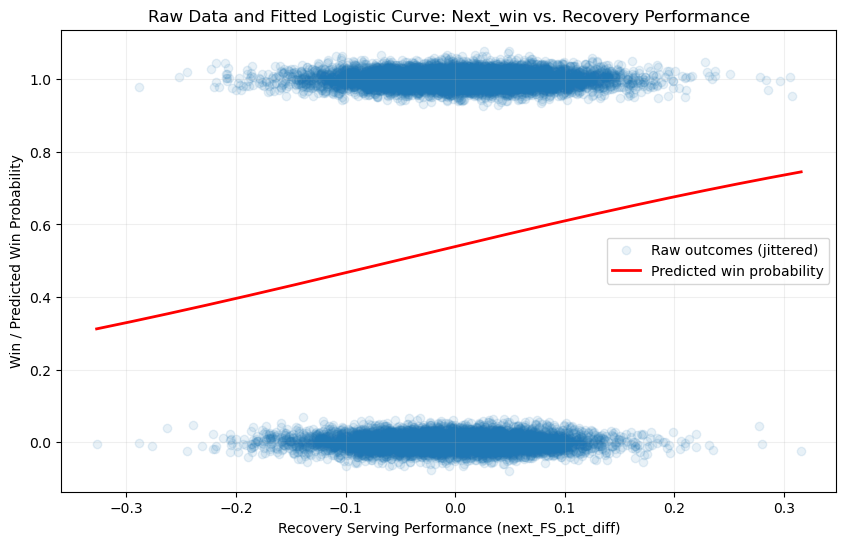

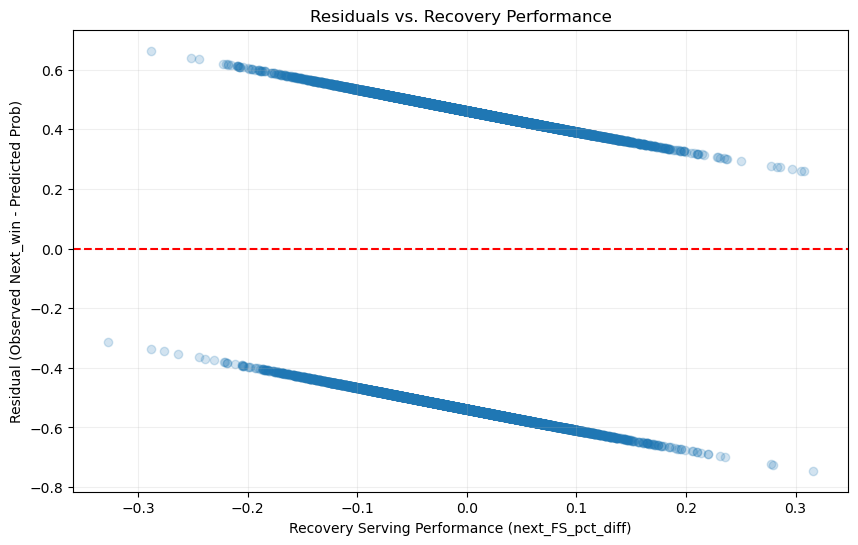

In [6]:
#H2 RAW DATA vs. FITTED CURVE

#fitted data predictor and outcome
x_raw = fatigue_df['next_FS_pct_diff']
y_raw = fatigue_df['next_win']

#predicted probabilities
X_full = sm.add_constant(x_raw)
p_raw = model.predict(X_full)

#jitter binary outcomes (visibility)
np.random.seed(42)
y_jitter = y_raw + np.random.normal(0, 0.02, size = len(y_raw))

#curve
x_range = np.linspace(x_raw.min(), x_raw.max(), 200)
X_curve = pd.DataFrame({
    'const': 1.0,
    'next_FS_pct_diff': x_range
})
p_curve = model.predict(X_curve)

plt.figure(figsize=(10, 6))
plt.scatter(x_raw, y_jitter, alpha = 0.1, label = 'Raw outcomes (jittered)')
plt.plot(x_range, p_curve, color='red', linewidth = 2,
         label = 'Predicted win probability')
plt.xlabel("Recovery Serving Performance (next_FS_pct_diff)")
plt.ylabel("Win / Predicted Win Probability")
plt.title("Raw Data and Fitted Logistic Curve: Next_win vs. Recovery Performance")
plt.legend()
plt.grid(alpha = 0.2)
plt.show()


#H2 RESIDUALS vs. PREDICTED PROB

#predicted probabilities
p_hat = model.predict(X_full)

#residuals: observed - predicted probability
residuals = y_raw - p_hat

plt.figure(figsize = (10, 6))
plt.scatter(x_raw, residuals, alpha = 0.2)
plt.axhline(0, color='red', linestyle = '--')
plt.xlabel("Recovery Serving Performance (next_FS_pct_diff)")
plt.ylabel("Residual (Observed Next_win - Predicted Prob)")
plt.title("Residuals vs. Recovery Performance")
plt.grid(alpha=0.2)
plt.show()

**Relationship Summary**

The model shows a strong and statistically significant positive relationship between recovery serving performance and winning the recovery match; specifically, Specifically, a 0.1 increase in `next_FS_pct_diff` multiplies the odds of winning the recovery match by e$^{0.28933}$ = 1.34. In other words, serving 10 percentage points better than one’s yearly average is associated with a 34% increase in the odds of winning the next match. The magnitude and direction of this coefficient are consistent with the idea that players who recover well after a fatiguing match gain a competitive advantage in their subsequent performance.

This is visually backed by the “Raw Data and Fitted Logistic Curve: Next_win vs. Recovery Performance (next_FS_pct_diff),” showing both the binary win outcomes (the two horitzal bands at 0/1 points) and the fitted logistic regression curve modeling predicted probabilities. The logistic curve slopes upward (constitnet with $\beta = 2.8933$), indicating that players who serve better than usual after a fatiguing match have higher predicted probabilities of winning their next match.


**Model Predictions**

**<u>I.</u>** 
This model indicates that a player whose first-serve percentage in the recovery match equals their yearly average (where `next_FS_pct_diff` = 0), then we expect their win probability to be 0.539. Derivation:

$$\text{logit}(P) = 0.1553 + 2.8933 * 0$$
$$= 0.1553$$

$$\text{and}$$

$$p = e^{0.1553} / (e^{0.1553} + 1)$$
$$= 0.539$$

So, a player who serves exactly at their yearly average after a fatiguing match has a predicted 60.9% chance of winning their next match.


**<u>II.</u>** 
When recovery performance is 0.10 (serving 10 percentage points better than a players yearly average), then we expect their win probability to be 0.609. Where the derivation of this is: 
$$\text{logit}(P) = 0.1553 + 2.8933 * 0.1$$
$$= 0.44463$$

$$\text{and}$$

$$p = e^{0.44463} / (e^{0.44463} + 1)$$
$$= 0.609$$

So, a player who serves 10 percentage points better than their yearly average after a fatiguing has a predicted 60.9% chance of winning their next match.


**<u>III.</u>** 
However, when recovery performance is -0.10 (serving 10 percentage points worse than average), we expect a player's probability of winning to be 0.467 derived by:
$$\text{logit}(P) = 0.1553 + 2.8933 * -0.1$$
$$= -0.13403$$

$$\text{and}$$

$$p = e^{-0.13403} / (e^{-0.13403} + 1)$$
$$= 0.4665$$

So, a player who serves 10 percentage points worse than their yearly average after a fatiguing match has a predicted 46.7% chance of winning their next match.

**Outliers/Oddities**

We expect this model to hold within the observed empirical range of `next_FS_pct_diff`, which lies roughly between -0.30 and +0.30 for most players. Predictions beyond this interval would constitute extrapolation, and the estimated positive relationship between recovery performance and next-win probability may no longer hold. For example, at recovery performance values far outside the data (e.g., +0.6 or –0.6), the model would continue to increase or decrease predicted win probability according to the linear log-odds function, even though such values may be physiologically impossible for players. This would produce nonsensical predictions such as probabilities approaching 0 or 1 with near certainty.

Under evalutation of match durations via the boxplot reveals several extremely long matches (with some exceeding 500 minutes). These are genuine tennis outliers (marathon matches) rather than data errors. Because we explicitly define “fatiguing matches” as those above the 75th percentile, these extreme values are preserved and appropriately included in the analysis. They may increase variability but do not appear to distort the model fit.

Addtionally,`next_FS_pct_diff` does not reveal any problematic outliers: the distribution is bounded by –1 and +1 and naturally centers near zero because most players’ performances fluctuate modestly around their yearly average.

Finally, the residual plot [displaying the difference between observed next-match outcomes and the predicted logistic model] doesn't reveal any observations with large errors or oddites. Though the residuals form two dense bands (roughly around 1 – p for observed wins and another around 0 – p for observed losses), this pattern is expected for logistic models as it preditcs continuout probabilities while the outcome itself is binary. Otherwise, it meets all expectations of homoskedasticity.

### Hypothesis 3: Surface Specilization
**Null Hypothesis $H_0$**: Playing on a player’s preferred surface does not affect their performance relative to opponent rank. The coefficient on “preferred surface” in the win-probability model (controlling for rank) is zero (_$B_{Surface}$ = 0_) and surface speclialists do _not_ outperform expectations.


**Alternative Hypothesis $H_1$**: Playing on a player’s preferred surface improves their performance relative to opponent rank. Surface specialists are more likely to win on that surface, even against higher-ranked opponents. In other words, _$B_{Surface}$ != 0_, we expect $B_{Surface}$ > 0.

In [7]:
# Logistic regression: win ~ rank_diff * surface_experience + surface fixed effects
model_h3 = smf.logit(
    formula="win ~ rank_diff * surface_experience",
    data=analysis_df
).fit()

print(model_h3.summary())

Optimization terminated successfully.
         Current function value: 0.692355
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                66029
Model:                          Logit   Df Residuals:                    66025
Method:                           MLE   Df Model:                            3
Date:                Fri, 05 Dec 2025   Pseudo R-squ.:               0.0006772
Time:                        23:01:47   Log-Likelihood:                -45716.
converged:                       True   LL-Null:                       -45747.
Covariance Type:            nonrobust   LLR p-value:                 2.246e-13
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -0.0603      0.020     -3.031      0.002

The logistic regression examines whether surface specialization (`surface_experience`) improves a player’s probability of winning, controlling for opponent strength via `rank_diff`, and - critically - whether specialization helps players overcome ranking disadvantages through the interaction term.

This Linear Model Predicts the Regression Curve:
$$\text{logit}(\Pr(\text{win}=1)) = -0.0603 + 0.0049(\text{rank\_diff}) + 0.2209(\text{surface\_experience}) - 0.0059(\text{rank\_diff} \times \text{surface\_experience})$$

**Relationship Summary**

The logistic regression model show surface specialization having a statistically significant positive relationship with a player’s probability of winning a match; specifically a 0.1 increase in specialization multiplies the odds of winning by e$^{0.2209 \times 0.1}$ = 1.022, meaning the odds increase by approximately 2.2% when rank difference is held constant.

On the other hand, rank differences, represented by `rank_diff`, show a smaller postiive (though stitiscally significant) relationship with winning. Because rank_diff represents the opponent’s rank minus the player’s rank, positive values indicate that the player is facing a weaker opponent. A 10-rank increase in rank_diff multiplies the odds of winning by e$^{0.0049 \times 5}$ = 1.024, corresponding to a 2.4 increase in the odds of winning, consistent with expectations.

The key parameter for Hypothesis 3 is the interaction term, `rank_diff:surface_experience`, which is negative and statistically significant; specifically, where a one-unit increase in the interaction term multiplies the odds of winning by e$^{-0.0059}$ = 0.994, meaning that when ranking gaps are extreme, surface specialization advantages are smaller and less relevant. In other words, specialization matters most in competitive, closely ranked matches, and contributes *less* when the player is already substantially stronger than the opponent.

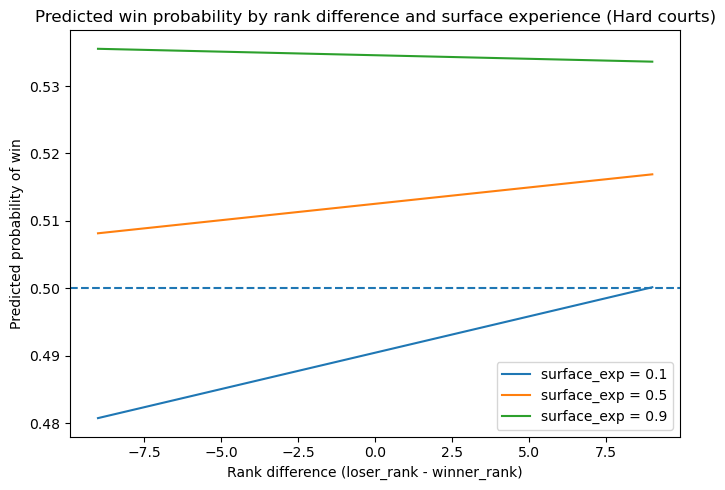

In [8]:
# Predicted probability grid for different values of rank_diff and surface_experience
rank_grid = np.linspace(analysis_df["rank_diff"].quantile(0.05),
                        analysis_df["rank_diff"].quantile(0.95),
                        50)
surf_exp_grid = [0.1, 0.5, 0.9]  # low, medium, high specialization

pred_rows = []
for se in surf_exp_grid:
    for rd in rank_grid:
        pred_rows.append({"rank_diff": rd, "surface_experience": se, "surface": "Hard"})  # choose a baseline surface

pred_df = pd.DataFrame(pred_rows)
pred_df["win_prob"] = model_h3.predict(pred_df)

plt.figure(figsize=(7,5))
for se in surf_exp_grid:
    subset = pred_df[pred_df["surface_experience"] == se]
    sns.lineplot(x="rank_diff", y="win_prob", data=subset, label=f"surface_exp = {se}")
plt.axhline(0.5, linestyle="--")
plt.xlabel("Rank difference (loser_rank - winner_rank)")
plt.ylabel("Predicted probability of win")
plt.title("Predicted win probability by rank difference and surface experience (Hard courts)")
plt.tight_layout()
plt.show()

**Model Predictions**

To illustrate the functionality of this model, we compute predicted win probabilities for players facing an equally ranked opponent (rank_diff = 0) at different levels of surface specialization. These probabilities are predicte dusing the regression equation above. 

I. The model indicates that for a player holding modest surface experience, where `surface_experience` = 0.1, we expect a 49.0% predicted probability of winning against an equally ranked opponent. This is derived by:

$$\text{logit}(p) = -0.0603 + 0.2209 * 0.1$$
$$= -0.03821$$

$$\text{and}$$

$$p = e^{-0.03821} / (e^{-0.03821} + 1)$$
$$= 0.490$$


II. Additionally, the model indicates that for a player holding modest surface experience, where `surface_experience` = 0.5, we expect a 51.2% predicted probability of winning against an equally ranked opponent. This is dervied by:

$$\text{logit}(p) = -0.0603 + 0.2209 * 0.5$$
$$= 0.05015$$

$$\text{and}$$

$$p = e^{0.05015} / (e^{0.05015} + 1)$$
$$= 0.512$$


III. Finally, the model indicates that for a player holding modest surface experience, where `surface_experience` = 0.9, we expect a 53.5% predicted probability of winning against an equally ranked opponent. This is dervied by:

$$\text{logit}(p) = -0.0603 + 0.2209 * 0.9$$
$$= 0.13851$$

$$\text{and}$$

$$p = e^{0.13851} / (e^{0.13851} + 1)$$
$$= 0.535$$


Together, these predictions illustrate surface specialization meaningfully shifts a player’s baseline probability of winning, consistent with a positive effect on performance.


The "predicted win probability by rank difference and surface experience (hard courts)" plot above visualizes these predictions of how surface specialization shapes a player’s likelihood of winning across different levels of opponent difficulty. Holding surface type constant (Hard courts), the model’s predicted win probabilities are plotted across a realistic range of rank differences (from tougher opponents to easier ones), separately for low (0.1), medium (0.5), and high (0.9) specialization. Consistent with the positive main effect of specialization, each line shifts upward as specialization increases: highly specialized players are predicted to win more often at every rank difference. The plot also visually reflects the negative interaction term—while low-specialization players show a clear upward slope as the opponent becomes weaker, the slope flattens for medium specialization and becomes almost flat for highly specialized players. This indicates that specialization provides its greatest benefit in competitive matches (rank_diff near zero), while offering less incremental advantage once the opponent is substantially weaker.

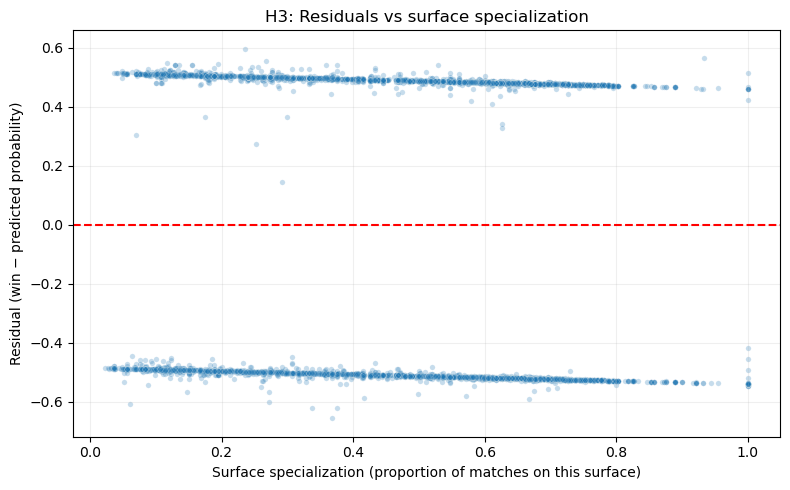

In [9]:
#residual plot (surface exp
#predicted probabilities
analysis_df = analysis_df.copy()
analysis_df["win_pred"] = model_h3.predict(analysis_df)

#Residuals
analysis_df["residual"] = analysis_df["win"] - analysis_df["win_pred"]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=analysis_df.sample(min(8000, len(analysis_df)), random_state=2),
    x="surface_experience",
    y="residual",
    alpha=0.25,
    s=15
)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Surface specialization (proportion of matches on this surface)")
plt.ylabel("Residual (win − predicted probability)")
plt.title("H3: Residuals vs surface specialization")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Extrapolation**

The model for Hypothesis 3 is appropriate for interpreting the relationship between match outcomes, ranking differences, and surface specialization. We expect the model to hold for specialization values between 0 and 1, since this represents the true domain of the variable (proportion of a player’s matches played on the given surface). Predictions outside this interval would be meaningless and should not be used.

Similarly, the model should only be applied to rank differences within the empirical range, approximately between the 5th and 95th percentiles. If the model is used to predict win probabilities for extreme ranking gaps: for example, when a highly specialized player faces an opponent ranked several hundred places above or below them, the interaction term may produce probabilities extremely close to 0 or 1. Although these values satisfy the logistic function mathematically, they are conceptually unrealistic, as tennis matches are rarely deterministic even when players’ rankings differ substantially. Thus, extrapolating beyond the central range of rank differences poses a risk of overinterpreting specialization effects in situations where ranking dominates match outcomes.

**Outliers/Oddities**

The dataset contains a small number of observations where specialization is extremely high (close to 1.0) or extremely low (near 0). These values are not statistical outliers - rathey they reflect real players whose competitive history is concentrated heavily on one surface. However, they reduce the model’s ability to estimate precisely at extremes. This explains the slight narrowing of the residual bands near specialization = 1.0 in the diagnostic plot.

The residual plot shows two horizontal bands (one near +0.5 for matches won and one near -0.5 for matches lost). This is the expected pattern for this model of a binary logistic regression. It is important to note that the bands remain roughly parallel and centered across specialization. Since there is no heterskedasticity present, this model appears to adequately capture the relationship between surface specialization and win probability.

Aside from isolated points, which fall well within plausible boundaries, there are no meaningful outliers that would indicate a structural issue with the model.

### Hypothesis 4: Interaction of Fatigue and Clutch Performance
**Null Hypothesis $H_0$**: Match duration (fatigue) is not related to clutch performance. Equivalently: the coefficient on match duration in the model predicting clutch performance is zero (_$B_{Duration}$ = 0_); where longer matches do not change clutch ability.

**Alternative Hypothesis $H_1$**: Longer, more fatiguing matches are associated with worse clutch performance on break points.  _$B_{Duration}$ != 0_.

In [10]:
# Linear regression: clutch ~ prev_minutes + rank + surface fixed effects
model_h4 = smf.ols(
    formula = "clutch ~ prev_minutes + rank + C(surface)",
    data = analysis_df
).fit()

print(model_h4.summary())

                            OLS Regression Results                            
Dep. Variable:                 clutch   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     21.85
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           6.23e-22
Time:                        23:01:48   Log-Likelihood:                -11397.
No. Observations:               66029   AIC:                         2.281e+04
Df Residuals:                   66023   BIC:                         2.286e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5332    

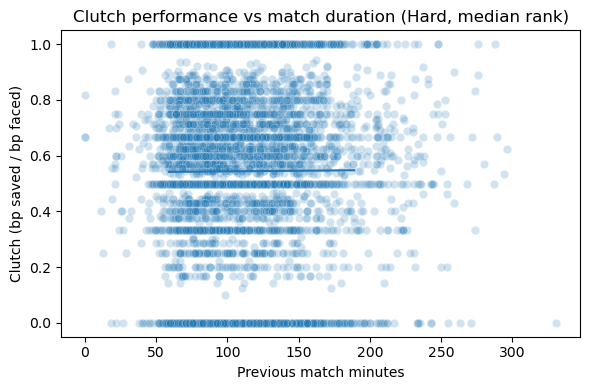

In [11]:
#Visualization: fitted line of clutch vs prev_minutes
#Take a slice for a typical rank and a fixed surface
median_rank = analysis_df["rank"].median()

plot_df = pd.DataFrame({
    "prev_minutes": np.linspace(
        analysis_df["prev_minutes"].quantile(0.05),
        analysis_df["prev_minutes"].quantile(0.95),
        100),
    "rank": median_rank,
    "surface": "Hard"})

plot_df["clutch_pred"] = model_h4.predict(plot_df)

plt.figure(figsize=(6,4))
sns.scatterplot(data=analysis_df.sample(min(5000, len(analysis_df))), x="prev_minutes", y="clutch", alpha=0.2)
sns.lineplot(data=plot_df, x="prev_minutes", y="clutch_pred")
plt.title("Clutch performance vs match duration (Hard, median rank)")
plt.xlabel("Previous match minutes")
plt.ylabel("Clutch (bp saved / bp faced)")
plt.tight_layout()
plt.show()

This Linear Model Predicts the Regression Curve:
$$\text{clutch} = 0.5332 + 0.0093(\text{Clay})+ 0.0408(\text{Grass}) + 0.0105(\text{Hard} + 4.501\times10^{-5}(\text{prev\_minutes})) - 9.604\times10^{-5}(\text{rank})$$

**Relationship Summary**

The linear regression model indicates no meaningful relationship between previous match duration and clutch performance. The coefficient on prev_minutes is extremely small ($\beta$ = 4.50*10$^{-5}$) and not statistically significant, where longer or more fatiguing matches do not meaningfully predict performance under break-point pressure in the next match. Concretely, the model does not provide evidence that accumulated fatigue carries over into a decline in clutch ability.


**Model Predictions**

Because the effect of previous match duration is so small, the model predicts nearly identical clutch values across realistic match-duration levels. We evaluate this at representative values of `prev_minutes`. Because clutch is a proportion between 0 and 1, these predicted values represent the expected share of break points saved in the next match.

I. The model indicates that after a 60 minute match, a player's clutch performance is expected to be:

$$\widehat{\text{clutch}} = 0.5332 + 4.50\times10^{-5}(60) = 0.5332 + 0.0027$$
$$= 0.5359$$

So, they are expected to save about 53.6% of the break points they face.

II. Additionally, the model indicates that after a 120 minute match, a player's clutch performance is expected to be:
$$\widehat{\text{clutch}} = 0.5332 + 4.50\times10^{-5}(120) = 0.5332 + 0.0054$$
$$= 0.5386$$

So, they are expected to save about 53.9% of the break points they face.

III. Finally, the model indicates that after a 180 minute match, a player's clutch performance is expected to be:
$$\widehat{\text{clutch}} = 0.5332 + 4.50\times10^{-5}(180) = 0.5332 + 0.0081$$
$$= 0.5413$$

So, they are expected to save about 54.1% of the break points they face.

Across all three predictios (60, 120, and 180 minutes), predicted clutch performance rises by merely 0.54 percentage points when increasing match duration by two full hours, signifying that match duration has no statistically significant effect on clutch performance.

**Outliers/Oddities**

In this dataset, the central 90% of matches fall between roughly 50 and 250 minutes, with a small number of extreme outliers above 350 minutes. Therefore, we expect the model to hold only for match durations within this empirically supported range.

Specifically, if used to predict clutch performance for match durations far outside this window (at extremely short or long matches above) the linear form may no longer be appropriate. At extreme values of `prev_minutes`, the model would eventually predict clutch values above 1, which is impossible because clutch performance is a proportion. At very low values of prev_minutes, the model could predict negative clutch values, which are similarly nonsensical. 

Visual inspection of this model using the "clutch performance versus match duration" scatterplot help contextualize this regression. Firstly, there is substantial vertical banding at clutch values around 0, 0.25, 0.5, 0.75, and 1. These bands occur because clutch is calculated as the proportion of break points saved, and players often face only a small number of break points in a match. When the denominator is small, the clutch metric takes on a limited set of discrete values that are visible in this "banded" form on the plot constructed. However it is important to note that this is a feature of the metric rather than a sign of the model not fitting the data well. 

Addtionally, the plot shows no visible downward slope, which aligns with the regression results that even as match duration increases, clutch performance does not parallelly decrease. This *lack* of a pattern evidences that fatigue from long matches does not deteriorate break-point performance. Instead, the fitted line is nearly horizontal which reinforces our exponentially small result.

## VI. Evaluation of Significance 

### Hypothesis 1: Short-Term Resilience: Clutch Performance and Success
1. **Coefficient Interpretation** <br>
The clutch β-hat coefficient is positive and large (`0.9649`). This means that for a 1-unit increase in the clutch index, the odds of winng will multiply by approximately 2.63 ($E^{β-hat}$). Since the clutch index ranges between 0-1, small increases are significant. For example, a 0.1 increase in clutch leads to a 0.1*(0.9649) = ~9.65% increase in the odds of winning.

2. **Significance Test** <br>
Becuase the p-value of `0.000` is far below the 0.05 alpha threshold and the z-score of `35.230` is greater than the 1.645 threshold for two-tailed tests, we reject the null hypothesis. The 95% confidence interval `(0.911 → 1.019)` does not include 0. <br>

This indicates that clutch performance is a statistically significant predictor of match outcomes. Specifically, players who perform better under pressure (converting and saving break points) have a substantially higher probability of winning matches. <br>

Although clutch explains a modest portion of variability in match outcomes (Pseudo R² = 0.014), the effect is practically meaningful in the context of professional tennis, where small performance differences can significantly influence match results.

### Hypothesis 2:  Long-Term Resilience: Recovery and Success¶
1. **Coefficient Interpretation** <br>
For a 1-unit increase in `next_FS_pct_diff` (meaning the player served 1.0 or 100 percentage points better than their yearly average), the model predicts an increase of about 2.897 in the log-odds of winning the next match. <br>
Since next_FS_pct_diff is typically small (e.g., 0.02 = +2 pp improvement): it might be more realistic to see that for a 0.01 increase in `next_FS_pct_diff` (serving 1 percentage point above yearly average), the log-odds of winning increase by 0.02897.

2. **Significance Test** <br>
Because the p-value of `0.000` is far below 0.05 and the z-score is `11.493` which is much larger than the rejection threshold of 1.645 for this two-tailed test, we reject the null hypothesis. The 95% confidence interval for β₁ `(2.403, 3.391)` does not include zero. <br>

Therefore, stronger recovery performance statictally significant in its association with higher short-term success, supporting our hypothesis about macro-level resilience. As demonstrated, serving better than one’s yearly average in the match after a fatiguing match increases the probability of winning that next match.

### Hypothesis 3: Surface Specialization
Our logistic regression tested whether surface specialization helps players overcome ranking disadvantages. The key results were:

- **rank_diff:** 0.0049, p < 0.001, 95% CI [0.0028, 0.0070]  
- **surface_experience:** 0.2209, p < 0.001, 95% CI [0.1485, 0.2933]  
- **rank_diff × surface_experience:** −0.0059, p < 0.001, 95% CI [−0.0087, −0.0031]

All three predictors are statistically significant under our threshold of α = 0.05.

The positive coefficient on `rank_diff` shows that players who are relatively better ranked are more likely to win. Surface experience also has a strong positive effect, meaning specialists win more often on their preferred playing surface.

However, the **interaction term is negative**, indicating that surface experience does not amplify the ability of lower-ranked players to upset stronger opponents. Instead, specialization slightly *reduces* the impact of rank difference, meaning specialists perform consistently well, but not disproportionately better when facing large ranking gaps.

**Conclusion for H3:**  
For H3, we tested the null hypothesis that surface experience does not interact with rank difference in predicting match outcomes. The interaction coefficient was statistically significant (p < 0.001) and its 95% confidence interval excluded zero. **Because p < 0.05, we reject the null hypothesis.** However, the interaction was negative, meaning surface experience does not help lower-ranked players overcome ranking disadvantages as predicted. Thus, the null is rejected, but H3 is only partially supported because the direction of the effect contradicts our preregistered expectation.

### Hypothesis 4: Interaction of Fatigue and Clutch Performance
The OLS regression tested whether players coming off longer previous matches perform worse on break points. The key coefficients were:

- **prev_minutes:** 0.0000450, p = 0.093, 95% CI [−0.0000076, 0.0000976]  
- **rank:** −0.000096, p < 0.001  
- **C(surface):** All p-values > 0.48 (not significant)

The coefficient for `prev_minutes` is **positive**, but importantly, it is **not statistically significant** at α = 0.05 because **p = 0.093 ≥ 0.05**, and the confidence interval includes zero. This means we cannot reliably conclude that fatigue affects clutch performance based on this model.

Ranking is a significant predictor, with lower-ranked (worse) players showing reduced clutch performance.

Surface type does not meaningfully affect clutch performance after controlling for rank and previous match duration.

**Conclusion for H4:**  
For H4, we tested the null hypothesis that previous match duration has no effect on clutch performance. Because the p-value for `prev_minutes` is **0.093**, which is greater than our α = 0.05 threshold, **we fail to reject the null hypothesis**. Although the coefficient is slightly positive, the effect is not statistically reliable. Therefore, H4 is **not supported**, as the data do not provide significant evidence that fatigue influences clutch performance in either direction.

## VII. Conclusion

In this project, we used ATP men’s match data from 2010–2024 to study how resilience shows up beyond rankings. We focused on two questions: (1) whether surface experience changes the usual advantage of higher-ranked players, and (2) whether fatigue is linked to worse performance on high-pressure points like break points.

For our first research question on long-term resilience and surface specialization, we found that both ranking and surface experience are important predictors of who wins. In the logistic regression model, rank difference (loser_rank − winner_rank) had a positive, statistically significant coefficient (0.0049, p < 0.001), meaning better-ranked players are more likely to win. Surface experience also had a strong positive coefficient (0.2209, p < 0.001), so players with more matches on a surface tend to perform better on that surface. The interaction between rank difference and surface experience was negative and significant (−0.0059, p < 0.001), which shows that surface experience slightly reduces how strongly rank difference predicts winning, but does not fully reverse ranking advantages. In other words, surface specialists do win more often on their preferred courts than ranking alone would predict, but the effect is modest rather than a complete shift in who is favored.

For our second research question on short-term resilience, fatigue, and clutch performance, we asked whether players perform worse on break points as matches get longer. In the OLS regression of clutch index on previous match duration (prev_minutes), rank, and surface, the coefficient on prev_minutes was very small and not statistically significant at the 0.05 level (4.50e−05, p ≈ 0.093, 95% CI includes 0). This means we do not find strong evidence that simply playing a longer previous match leads to systematically worse clutch performance in the next one. Rank did matter—lower-ranked players had significantly lower clutch values—and surface indicators were not significant once other variables were included. Taken together, this suggests that our simple fatigue proxy (match minutes) is not enough on its own to detect a clear decline in clutch performance.

Across our preregistered models, we also saw that clutch and recovery themselves are important parts of resilience, even if fatigue does not directly predict clutch. The logistic regression of win on clutch index showed a large, positive, highly significant coefficient (about 0.96, p < 0.001), meaning players with higher clutch performance are more likely to win. In the recovery analysis, serving better than one’s yearly average in the match after a long, fatiguing match (next_FS_pct_diff) was also strongly associated with a higher probability of winning that next match (coefficient = 2.90, p < 0.001). These results support the idea that both in-match clutch play and post-fatigue recovery are meaningful components of resilience.

Overall, our findings suggest that resilience in professional tennis is multi-dimensional. Surface experience provides a real but limited edge on preferred courts, clutch performance and post-fatigue recovery both have clear links to winning, and we do not see a strong direct effect of fatigue on clutch performance when using match duration alone. Given our limitations—no point-level data, a focus on modern ATP singles, and simple fatigue measures—these patterns should be read as evidence of how ranking, experience, recovery, and decision-making all interact, rather than as proof that any single factor fully explains resilience on tour.

## VIII. Limitations 

Despite being one of the most comprehensive archives of professional men’s tennis, the following limitations may limit the scope and interpretation of results drawn.

### Uneven Data Coverage
Although the ATP match-level files extend back to the 1970s, complete match-statistics fields (e.g., minutes, bpSaved, bpFaced) are consistently available only from the mid-2000s onward. Restricting the analysis window to 2010–2024 minimizes this issue but also excludes earlier eras of play, limiting the generalizability of findings to the modern ATP era. In practice, our models are really describing how current ATP tennis behaves, not how the game looked in previous decades.

### Lack of Point-Level and Contextual Variables
The files provide aggregate match statistics only; they do not include point-by-point or in-match sequencing data. Consequently, important contextual factors – such as score state, crowd influence, or weather – cannot be modeled. This constrains “clutch performance” analyses to represent measures like break-point conversion and tiebreak outcomes rather than genuine high-pressure point-level behavior. As a result, our clutch metrics are approximate: they summarize how players perform in key situations overall, but they cannot capture exactly when pressure was highest or why a player may have struggled in a specific moment.

### Exclusion of Doubles and Non-Tour Events
This project focuses exclusively on singles matches; doubles data are incomplete after 2020 and excluded entirely here. Davis Cup, exhibition, and many lower-level events – often lacking full statistics – are also filtered out. As a result, the dataset does not represent the full distribution of professional competition or total player workload. Our conclusions about fatigue and resilience apply mainly to ATP singles schedules and may not reflect how players manage energy when they also play doubles or national-team events.

### Survivorship and Selection Bias
Players who frequently withdraw, retire, or compete mainly in under-recorded circuits are under-represented. Similarly, higher-ranked players appear more often in later-round matches, which can influence resulting “fatigue” conclusions. This skews the data toward more successful and durable players, and it means our results are more about how top and mid-level pros behave than about the entire population of professional players. Patterns we see around match length, surface, and clutch performance may look different for lower-ranked or less frequently recorded players.

### No direct measure of fatigue
We use match duration in minutes as a simple proxy for fatigue. This does not capture everything that makes a player tired (travel, number of matches in a row, injuries, etc.), so our fatigue results should be read as approximate and may mix true fatigue effects with other unobserved factors.

### Rest Metrics
Some derived variables – particularly rest days – contained NaN values for players competing in their first recorded ATP match, since no prior event existed to calculate the interval between matches. These missing cases were excluded during data cleaning to prevent regression errors. Though this improved model performance, it slightly reduces sample size and limits analysis of first-time players. Any conclusions involving rest-based variables are therefore based on players with some match history in the dataset, not on newcomers.

### Contextual Boundaries
Professional tennis has evolved – rule changes (e.g., tiebreak formats), surface speeds, and training improvements – so findings from 2010–2024 should not be extrapolated to historical eras. The dataset also omits contextual shocks such as pandemic-era schedule disruptions, which may influence rest-day calculations in 2020–2021. For our analysis, this means we interpret resilience patterns as “how modern ATP tennis works now” and are cautious about reading too much into differences that could be driven by one-off calendar changes rather than stable long-term trends.

## IX. Bibliography

1. Sackmann, J. *ATP Match Results*. Tennis Abstract / GitHub repository. Available at: https://github.com/JeffSackmann/tennis_atp
2. Afremow, J. (2015). The Champion’s Mind: How Great Athletes Think, Train, and Thrive. Rodale
Books, Emmaus, Pennsylvania
3. Cohn, J. (2018) The Most Dominant Players on Every Surface in Tennis History.

## X. Questions for Reviewers

1. Does the functional form of each regression model seem appropriate given the structure of the dependent variables (binary vs. proportional vs. continuous)?
2. Are there alternative transformations (for example when clutch values when few break points are faced) that might address the banding and heteroscedasticity visible in the raw-data plots?
4. Are there other methods/dianostics that you think would give a more complete assessment of model quality?
5. What are ways to simplify/reformat things to improve readability for a general audience?